In [1]:
from kalman import LinearPhysics, emerge_obs
from tracker import Tracker, per_point_cov
from detect import PoseDetector
from camera import Camera, triangulate_undistorted

import json
import cv2
import torch
torch.set_float32_matmul_precision('high')

In [2]:
frames = []
all_cams = []
all_caps = []

for i in range(4):
    cap = cv2.VideoCapture(f"./data/salsa/PosterSession/cam{i}.avi")
    ret, frame = cap.read()
    assert ret
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = torch.from_numpy(frame).to("cuda")
    frames.append(frame)
    all_caps.append(cap)
    cam = Camera()
    cam.load_ini(f"./data/salsa/cam{i}.ini")
    cam.to("cuda")
    all_cams.append(cam)

In [3]:
detect = PoseDetector()
detect.to("cuda")

In [4]:
dyn_mat = torch.concat([
    torch.concat([torch.zeros(17*3, 17*3), torch.eye(3*17)], dim=1),
    torch.concat([torch.zeros(17*3, 17*3), torch.eye(3*17)*-0.5], dim=1)
], dim=0)
dyn_cov = torch.diag(torch.tensor([0.01]*3*17 + [1]*3*17))

physics = LinearPhysics(dyn_mat, dyn_cov)
physics.to("cuda")

In [5]:
tracker = Tracker(detect, physics)

In [6]:
cams = all_cams
imgs = frames

detections = detect.detect(cams, imgs)

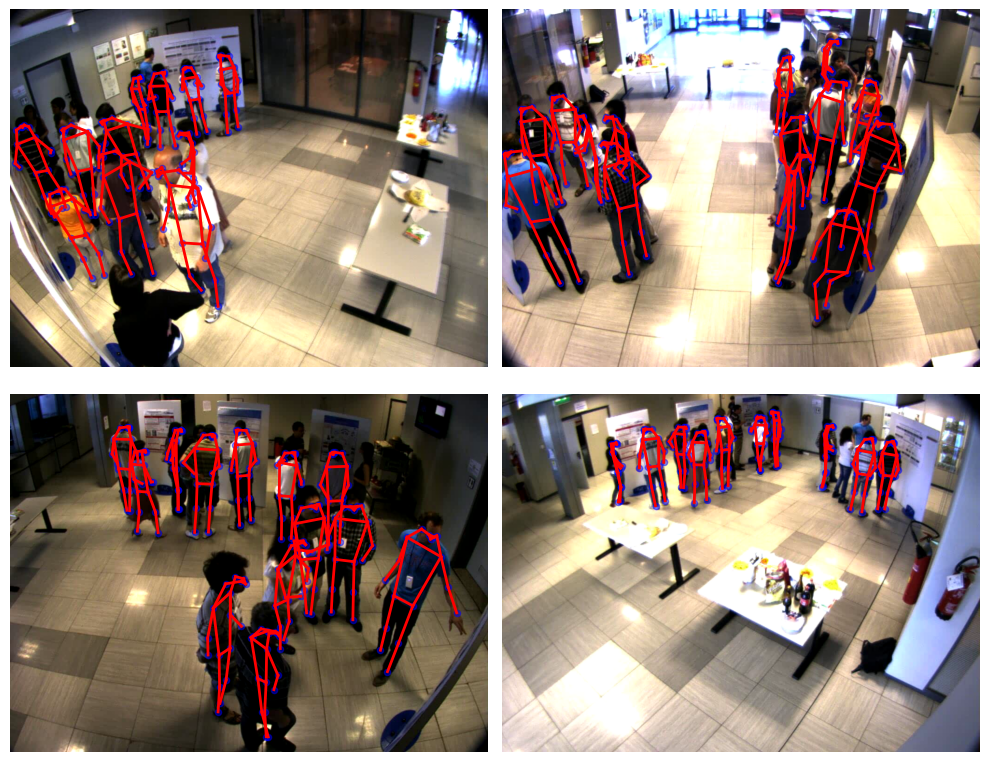

In [7]:
import matplotlib.pyplot as plt

def plt_detect(cam, detections, axes, i = 0):
    skeleton = [[15, 13], [13, 11], [16, 14], [14, 12], [11, 12], [5, 11], [6, 12], [5, 6], [5, 7], [6, 8], [7, 9], [8, 10], [1, 2], [0, 1], [0, 2], [1, 3], [2, 4], [3, 5], [4, 6]]
    kpts = cam.distort_points(detections[0].view(-1, 17, 2))
    # for kp, cov in zip(kpts[i:i+1].cpu(), detections[1][i:i+1].cpu()):
    for kp, cov in zip(kpts.cpu(), detections[1].cpu()):
        cov = torch.diag(cov).view(17, 2)
        for i, j in skeleton:
            if cov[i, 0] < 0.5 and cov[j, 0] < 0.5:
                axes.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='red', linewidth=2)
        for k in range(17):
            if cov[k, 0] < 0.5:
                axes.scatter(kp[k, 0], kp[k, 1], s=20, color='#0000ff70')

_, axs = plt.subplots(2, 2, figsize=(10, 8))
axs[0, 0].imshow(imgs[0].cpu().numpy())
plt_detect(cams[0], detections[0], axs[0, 0], 0)
axs[0, 0].axis("off")
axs[0, 1].imshow(imgs[1].cpu().numpy())
plt_detect(cams[1], detections[1], axs[0, 1], 12)
axs[0, 1].axis("off")
axs[1, 0].imshow(imgs[2].cpu().numpy())
plt_detect(cams[2], detections[2], axs[1, 0], 8)
axs[1, 0].axis("off")
axs[1, 1].imshow(imgs[3].cpu().numpy())
plt_detect(cams[3], detections[3], axs[1, 1], 1)
axs[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [8]:
tracker.update(all_cams, frames)

In [9]:
for i in range(1, 1500):
    tracker.predict(1 / 15)
    frames = []
    for cap in all_caps:
        ret, frame = cap.read()
        assert ret
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = torch.from_numpy(frame).to("cuda")
        frames.append(frame)
    tracker.update(all_cams, frames)
    with open(f"data/demo/{i}.json", "w") as file:
        tracks = [{
            "id": track.id,
            "kpts": track.get_keypoints().tolist(),
            "covs": track.get_covariances().tolist()
        } for track in tracker.get_prediction()]
        json.dump(tracks, file)